# Speech Recognition - Sesi 3
## MFCC Part 1: Introduction to MFCC & Create MFCC using Audio Library

**Binus University | Speech Recognition Laboratory**

---

### Outline
| Bagian | Topik |
|---|---|
| 1 | Apa itu MFCC? Feature extraction, time domain vs frequency domain |
| 2 | Mel Scale & Cepstral Coefficients (+ eksperimen kecil) |
| 3 | 6 Langkah MFCC (gambaran besar) |
| 4 | Setup: import library & membaca file audio |
| 5 | Langkah 1 — Normalization |
| 6 | Langkah 2 — Frame Blocking |
| 7 | Langkah 3 — Windowing |
| 8 | Langkah 4 — Fast Fourier Transform (FFT) & Power Spectrum |
| 9 | Rangkuman, preview Sesi 4, dan latihan |

> **Sesi 3 (Part 1)** = teori MFCC secara utuh + implementasi langkah 1–4.
> **Sesi 4 (Part 2)** = melanjutkan langkah 5–6 (Mel Filterbank & DCT) sampai MFCC jadi.

---
# Bagian 1 - Apa itu MFCC?

## 1.1 Feature Extraction

Komputer tidak bisa "mendengar". Yang komputer lihat dari sebuah file audio hanyalah **deretan angka** (amplitudo per waktu) — bisa ratusan ribu angka untuk rekaman beberapa detik saja. Angka mentah ini terlalu banyak dan terlalu "berisik" untuk langsung dipakai oleh model machine learning.

Karena itu kita butuh **feature extraction**: mengubah sinyal mentah menjadi **fitur** — representasi numerik yang jauh lebih ringkas tetapi tetap menyimpan karakteristik penting dari suara.

> **Fitur** = properti/karakteristik terukur dari data, yang dipakai sebagai input untuk melatih model dan membuat prediksi.

**MFCC (Mel-Frequency Cepstral Coefficients)** adalah metode feature extraction paling populer untuk speech recognition. Namanya menjelaskan isinya:

| Kata | Arti |
|---|---|
| **Mel-Frequency** | frekuensi diukur memakai *Mel scale*, skala yang meniru pendengaran manusia |
| **Cepstral** | fitur diambil dari *cepstrum* ("spektrum dari spektrum") |
| **Coefficients** | hasil akhirnya berupa sekumpulan koefisien (angka), biasanya 12–13 per frame |

**Tujuan MFCC:** meringkas sinyal suara menjadi beberapa angka per potongan waktu, yang menggambarkan *bentuk spektrum* suara sesuai cara manusia mendengarnya — sehingga model bisa membedakan kata, fonem, atau penutur.

## 1.2 Time Domain vs Frequency Domain

| | Time Domain | Frequency Domain |
|---|---|---|
| Sumbu X | waktu (detik) | frekuensi (Hz) |
| Sumbu Y | amplitudo | kekuatan sinyal pada frekuensi tersebut |
| Bentuk | gelombang (waveform) | spektrum |

File `.wav` yang kita baca berada di **time domain**. Namun untuk speech recognition, informasi yang penting — *suara vokal "a" vs "i"*, *suara laki-laki vs perempuan* — jauh lebih mudah dilihat di **frequency domain**, karena tiap bunyi punya "sidik jari" frekuensi yang khas.

Karena itu, inti dari MFCC adalah: **ubah sinyal ke frequency domain, lalu rangkum spektrumnya dengan cara yang meniru telinga manusia.**

---
# Bagian 2 - Mel Scale & Cepstral Coefficients

## 2.1 Eksperimen: apakah telinga kita linear?

Buka **Tone Generator** (https://www.szynalski.com/tone-generator/) dan dengarkan dua pasang nada berikut:

| Pasangan | Selisih frekuensi | Terdengar |
|---|---|---|
| C2 (65 Hz) → C4 (262 Hz) | ± 197 Hz | perbedaannya **sangat jelas** (2 oktaf) |
| G6 (1568 Hz) → A6 (1760 Hz) | ± 192 Hz | perbedaannya **tipis** (hanya 1 nada) |

Selisih Hz-nya hampir sama, tapi telinga kita merasakannya sangat berbeda. Artinya: **persepsi manusia terhadap frekuensi tidak linear.** Di frekuensi rendah kita sangat sensitif terhadap perubahan kecil; di frekuensi tinggi, perubahan harus besar baru terasa.

## 2.2 Mel Scale

**Mel scale** adalah skala frekuensi yang dirancang agar *jarak yang sama di skala Mel terdengar sama oleh manusia*. Skalanya hampir **linear di frekuensi rendah** (< 1000 Hz) dan **logaritmik di frekuensi tinggi**. Titik referensinya: **1000 Hz = 1000 Mel**.

Rumus konversi Hz → Mel:

$$\text{Mel}(f) = 2595 \times \log_{10}\left(1 + \frac{f}{700}\right)$$

Rumus konversi Mel → Hz:

$$f(\text{Mel}) = 700 \times \left(10^{\frac{\text{Mel}}{2595}} - 1\right)$$

- **700** : titik transisi di mana skala berubah dari linear ke logaritmik
- **2595** : konstanta empiris agar hasilnya cocok dengan eksperimen persepsi manusia

Mari kita buktikan dengan kode.

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Hz -> Mel
def freq_to_mel(freq):
    return 2595.0 * np.log10(1.0 + freq / 700.0)

# Mel -> Hz
def mel_to_freq(mels):
    return 700.0 * (10 ** (mels / 2595.0) - 1)

# Titik referensi: 1000 Hz ~ 1000 Mel
print(f"1000 Hz  = {freq_to_mel(1000):.1f} Mel")
print(f"1000 Mel = {mel_to_freq(1000):.1f} Hz")

1000 Hz  = 1000.0 Mel
1000 Mel = 1000.0 Hz


In [29]:
# Eksperimen dari slide: selisih Hz sama, tapi selisih Mel berbeda
pasangan = [(65, 262), (1568, 1760), (100, 300), (1100, 1300)]

print(f"{'Dari (Hz)':>10} {'Ke (Hz)':>8} | {'Selisih Hz':>10} | {'Selisih Mel':>11}")
print("-" * 48)
for f1, f2 in pasangan:
    selisih_hz  = f2 - f1
    selisih_mel = freq_to_mel(f2) - freq_to_mel(f1)
    print(f"{f1:>10} {f2:>8} | {selisih_hz:>10} | {selisih_mel:>11.1f}")

 Dari (Hz)  Ke (Hz) | Selisih Hz | Selisih Mel
------------------------------------------------
        65      262 |        197 |       258.2
      1568     1760 |        192 |        91.6
       100      300 |        200 |       251.5
      1100     1300 |        200 |       118.7


Perhatikan: 100→300 Hz dan 1100→1300 Hz sama-sama berjarak 200 Hz, tetapi di skala Mel jaraknya jauh berbeda. Skala Mel-lah yang cocok dengan apa yang kita dengar.

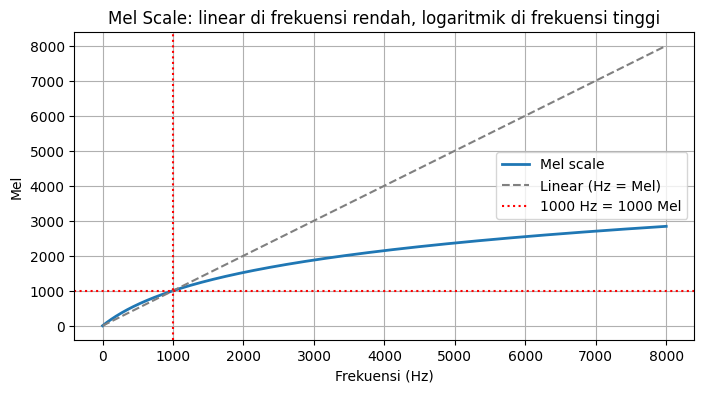

In [30]:
# Plot kurva Hz vs Mel
hz  = np.linspace(0, 8000, 500)
mel = freq_to_mel(hz)

plt.figure(figsize=(8, 4))
plt.plot(hz, mel, linewidth=2, label="Mel scale")
plt.plot(hz, hz, "--", color="gray", label="Linear (Hz = Mel)")
plt.axvline(1000, color="red", linestyle=":", label="1000 Hz = 1000 Mel")
plt.axhline(1000, color="red", linestyle=":")
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Mel")
plt.title("Mel Scale: linear di frekuensi rendah, logaritmik di frekuensi tinggi")
plt.legend()
plt.grid(True)
plt.show()

## 2.3 Cepstral Coefficients

Setelah spektrum diubah ke skala Mel, langkah terakhir MFCC adalah menghitung **cepstral coefficients** — sekumpulan angka yang merangkum *bentuk umum* spektrum (envelope) tanpa detail-detail kecilnya.

Istilah **cepstrum** adalah permainan kata dari *spectrum* (huruf "spec" dibalik menjadi "ceps"). Intinya: cepstrum = *spektrum dari log-spektrum*. Dengan mengambil beberapa koefisien pertama saja, kita mendapatkan fitur yang:

- **ringkas** — hanya 12–13 angka per frame, bukan ribuan
- **tidak saling berkorelasi** — setiap koefisien membawa informasi yang berbeda
- **menggambarkan bentuk vocal tract** — hal yang membedakan bunyi "a", "i", "u", dsb.

Cepstral coefficients inilah **hasil akhir** proses ekstraksi fitur MFCC yang akan dimasukkan ke model.

---
# Bagian 3 - 6 Langkah MFCC (Gambaran Besar)

```
 audio.wav
    │
    ▼
 ┌──────────────────┐  amplitudo diseragamkan ke rentang -1 s.d. 1
 │ 1. Normalization │
 └──────────────────┘
    ▼
 ┌──────────────────┐  audio dipotong jadi frame-frame pendek (20-40 ms) yang overlap
 │ 2. Frame Blocking│
 └──────────────────┘
    ▼
 ┌──────────────────┐  ujung tiap frame dihaluskan mendekati 0 (window function)
 │ 3. Windowing     │
 └──────────────────┘
    ▼
 ┌──────────────────┐  time domain -> frequency domain (per frame)
 │ 4. FFT           │
 └──────────────────┘
    ▼
 ┌──────────────────┐  spektrum dikelompokkan ke pita-pita Mel (meniru telinga)   ── Sesi 4
 │ 5. Mel Filterbank│
 └──────────────────┘
    ▼
 ┌──────────────────┐  ambil koefisien utama -> Cepstral Coefficients             ── Sesi 4
 │ 6. DCT           │
 └──────────────────┘
    ▼
  MFCC  (matriks: jumlah_frame x jumlah_koefisien)
```

| Langkah | Tujuan singkat |
|---|---|
| 1. Normalization | Menstandarisasi amplitudo agar volume konsisten di seluruh rekaman |
| 2. Frame Blocking | Memecah suara menjadi frame pendek supaya sinyal bisa dianggap *stasioner* |
| 3. Windowing | Menghindari distorsi akibat pemotongan frame (menghaluskan ujung frame) |
| 4. FFT | Mengubah sinyal dari time domain ke frequency domain |
| 5. Mel Filterbank | Mengubah spektrum frekuensi ke skala Mel |
| 6. DCT | Mengambil fitur utama (cepstral coefficients) |

Hari ini kita implementasikan langkah **1 sampai 4** menggunakan library audio Python.

---
# Bagian 4 - Setup: Import Library & Membaca File Audio

## 4.1 Import Library

| Library | Kegunaan |
|---|---|
| `numpy` | kalkulasi matematika & array |
| `scipy.io.wavfile` | membaca file audio `.wav` |
| `scipy.fftpack` | Fast Fourier Transform (FFT) |
| `scipy.signal.get_window` | membuat window function |
| `matplotlib.pyplot` | plotting hasil |
| `IPython.display.Audio` | memutar audio langsung di notebook |

In [31]:
import numpy as np                      # untuk kalkulasi matematika
from scipy.io import wavfile            # untuk input audio dari file wav
import scipy.fftpack as fft             # untuk Fast Fourier Transform (FFT)
from scipy.signal import get_window     # untuk windowing
import matplotlib.pyplot as plt         # untuk plotting hasil
from IPython.display import Audio       # untuk memutar audio di notebook

## 4.2 Membaca File Audio

`wavfile.read(path)` mengembalikan dua hal:
1. **sample rate** — berapa sample per detik (Hz)
2. **audio** — array NumPy berisi amplitudo tiap sample

**Sample rate** menentukan berapa banyak angka yang mewakili 1 detik suara. Contoh: 44100 Hz berarti 1 detik = 44100 angka.

In [32]:
# Path file audio (file ada di folder yang sama dengan notebook ini)
TRAIN_PATH = './audio.wav'

# Ambil sample rate dan data audio dari file wav
sample_rate, audio = wavfile.read(TRAIN_PATH)

print(f"Sample rate : {sample_rate} Hz")
print(f"Shape audio : {audio.shape}")
print(f"Tipe data   : {audio.dtype}")
print(f"Nilai min   : {audio.min()}")
print(f"Nilai max   : {audio.max()}")

Sample rate : 44100 Hz
Shape audio : (831744, 2)
Tipe data   : int16
Nilai min   : -26918
Nilai max   : 31064


Perhatikan `shape`-nya: `(jumlah_sample, 2)`. Angka **2** berarti audio ini **stereo** (kanal kiri & kanan). Untuk MFCC kita cukup memakai **1 kanal (mono)** — cara paling sederhana adalah merata-ratakan kedua kanal.

> Tipe data `int16` berarti nilai amplitudo berada di rentang -32768 s.d. 32767. Ini yang nanti kita normalisasi.

In [33]:
# Ubah stereo -> mono dengan merata-ratakan kedua kanal (axis=1 = arah kolom)
if audio.ndim == 2:
    audio = audio.mean(axis=1)

# Hitung durasi audio: jumlah sample dibagi sample per detik
audio_duration = len(audio) / sample_rate

print(f"Shape audio (mono) : {audio.shape}")
print(f"Jumlah sample      : {len(audio)}")
print(f"Durasi audio       : {audio_duration:.2f} detik")

Shape audio (mono) : (831744,)
Jumlah sample      : 831744
Durasi audio       : 18.86 detik


In [34]:
# Dengarkan audionya (after)
Audio(audio, rate=sample_rate)

## 4.3 Plot Waveform (Time Domain)

Kita buat sumbu X berupa waktu (detik) dengan `np.linspace(0, durasi, jumlah_sample)` — satu titik untuk tiap sample.

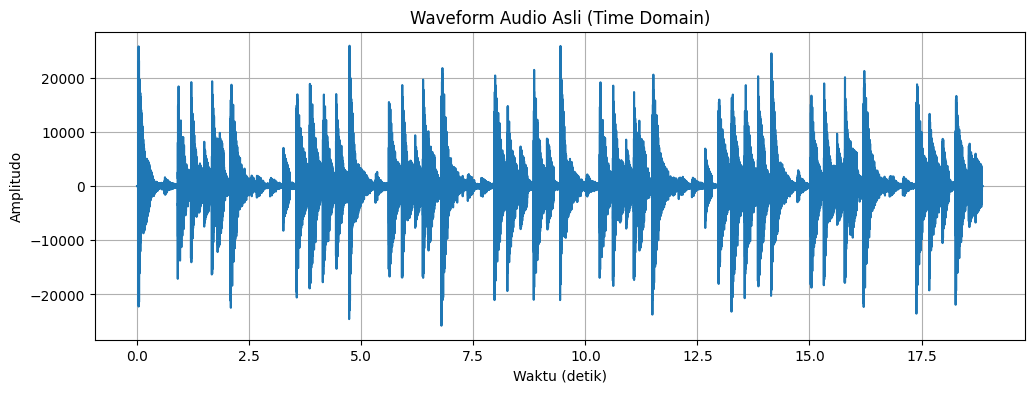

In [35]:
# Sumbu waktu: dari 0 sampai durasi, sebanyak jumlah sample
waktu = np.linspace(0, audio_duration, num=len(audio))

plt.figure(figsize=(12, 4))
plt.plot(waktu, audio)
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.title("Waveform Audio Asli (Time Domain)")
plt.grid(True)
plt.show()

---
# Bagian 5 - Langkah 1: Normalization

**Masalah:** rekaman yang berbeda bisa punya volume yang berbeda — satu direkam dekat mic, satu jauh. Kalau dibiarkan, model akan "belajar" perbedaan volume, bukan perbedaan isi suara.

**Solusi:** normalisasi amplitudo ke rentang **-1 sampai 1** dengan membagi seluruh sinyal dengan **nilai absolut maksimumnya**:

$$x_{norm}[n] = \frac{x[n]}{\max\left(|x|\right)}$$

- `np.abs(audio)` → semua nilai jadi positif (nilai negatif "dibalik")
- `np.max(...)` → cari nilai terbesar
- bagi seluruh audio dengan nilai itu → nilai terbesar menjadi tepat 1 (atau -1)

Bentuk gelombangnya **tidak berubah**, hanya skalanya yang diseragamkan.

In [36]:
def normalize_audio(audio):
    # Bagi audio dengan nilai absolut maksimumnya
    audio = audio / np.max(np.abs(audio))
    return audio

audio = normalize_audio(audio)

print(f"Nilai min setelah normalisasi : {audio.min():.4f}")
print(f"Nilai max setelah normalisasi : {audio.max():.4f}")

Nilai min setelah normalisasi : -0.9950
Nilai max setelah normalisasi : 1.0000


Exception ignored in: <function Wave_write.__del__ at 0x000001B5A489F560>
Traceback (most recent call last):
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\wave.py", line 465, in __del__
    self.close()
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\wave.py", line 583, in close
    self._ensure_header_written(0)
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\wave.py", line 606, in _ensure_header_written
    self._write_header(datasize)
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\wave.py", line 610, in _write_header
    self._file.write(b'RIFF')
ValueError: I/O operation on closed file.


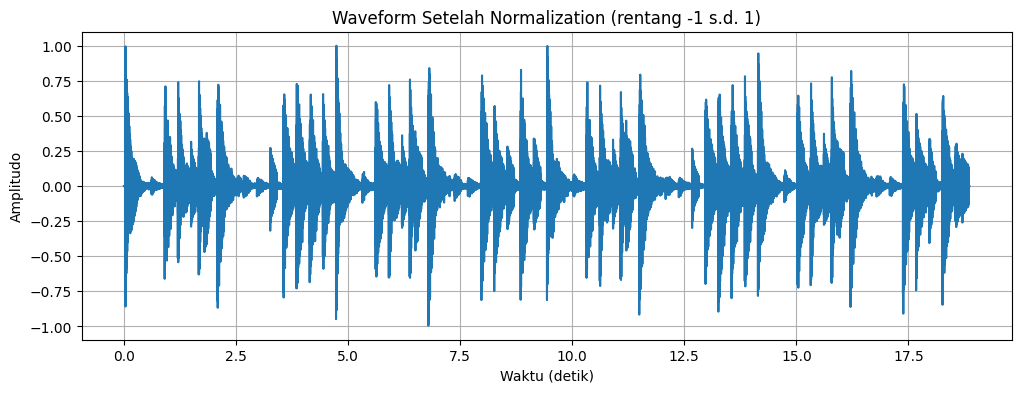

In [37]:
plt.figure(figsize=(12, 4))
plt.plot(waktu, audio)
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.title("Waveform Setelah Normalization (rentang -1 s.d. 1)")
plt.grid(True)
plt.show()

---
# Bagian 6 - Langkah 2: Frame Blocking

## 6.1 Kenapa harus dipotong-potong?

FFT (langkah 4) bekerja dengan asumsi sinyal bersifat **stasioner** — karakteristiknya tidak berubah terhadap waktu. Padahal suara manusia **non-stasioner**: dalam 1 detik kita bisa mengucapkan beberapa bunyi berbeda. Kalau FFT langsung diterapkan ke seluruh rekaman, semua frekuensi dari semua bunyi akan tercampur dan hasilnya tidak bermakna.

**Solusi:** potong sinyal menjadi **frame** yang sangat pendek (**20–40 ms**). Dalam durasi sependek itu, sinyal bisa dianggap stasioner sehingga FFT bekerja akurat di tiap frame.

## 6.2 Overlapping

Frame dibuat **saling tumpang tindih (overlap)**: akhir dari sebuah frame adalah awal dari frame berikutnya. Tujuannya menjaga **kontinuitas informasi** — supaya bunyi yang kebetulan berada di batas antar frame tidak hilang, dan transisi antar frame tetap mulus.

```
audio :  |-----------------------------------------------------|
frame 0: [==========]
frame 1:      [==========]
frame 2:           [==========]
frame 3:                [==========]
              ^ hop      ^ hop
```

## 6.3 Parameter yang dipakai

| Parameter | Arti | Nilai kita |
|---|---|---|
| `FFT_SIZE` | jumlah sample dalam 1 frame (= panjang frame). Dipilih pangkat 2 (512, 1024, 2048, …) supaya FFT cepat | 2048 |
| `HOP_SIZE` | jarak lompatan dari awal frame ke awal frame berikutnya, dalam **milidetik** | 15 ms |

Dengan sample rate 44100 Hz, 1 frame = 2048 / 44100 ≈ **46 ms**, dan hop = 15 ms → setiap frame overlap sekitar 2/3 dengan frame sebelumnya.

## 6.4 Langkah-langkah di kode

1. **Padding** — tambahkan `FFT_SIZE/2` sample di awal dan akhir audio dengan mode `reflect` (cermin dari audio itu sendiri), supaya bagian paling awal dan paling akhir audio tetap "kebagian" berada di tengah frame.
2. **`frame_len`** — ubah `HOP_SIZE` dari milidetik ke jumlah sample: `sample_rate * HOP_SIZE / 1000`.
3. **`frame_num`** — hitung berapa frame yang bisa dibuat: `(len(audio) - FFT_SIZE) / frame_len + 1`.
4. Siapkan array kosong `frames` berukuran `(frame_num, FFT_SIZE)`, lalu isi tiap barisnya dengan potongan audio.

In [38]:
FFT_SIZE = 2048   # jumlah sample per frame
HOP_SIZE = 15     # lompatan antar frame (ms)

def frame_blocking(audio, FFT_SIZE, HOP_SIZE, sample_rate):
    # 1. Padding: tambahkan FFT_SIZE/2 sample di awal & akhir (mode reflect = cermin)
    audio = np.pad(audio, int(FFT_SIZE / 2), mode="reflect")

    # 2. Panjang lompatan (hop) dalam sample: ms -> detik -> sample, dibulatkan ke int
    frame_len = np.round(sample_rate * (HOP_SIZE / 1000)).astype(int)

    # 3. Jumlah frame yang bisa dibuat
    #    dikurangi FFT_SIZE supaya frame terakhir tetap utuh, +1 untuk frame pertama
    frame_num = int((len(audio) - FFT_SIZE) / frame_len) + 1

    # 4. Kerangka array 2D berisi 0, ukuran (jumlah frame x panjang frame)
    frames = np.zeros((frame_num, FFT_SIZE))

    # 5. Isi tiap frame dengan potongan audio sepanjang FFT_SIZE
    for i in range(frame_num):
        frames[i] = audio[i * frame_len : i * frame_len + FFT_SIZE]

    return frames

framed_audio = frame_blocking(audio, FFT_SIZE, HOP_SIZE, sample_rate)

print(f"Shape frames        : {framed_audio.shape}  -> (jumlah frame, sample per frame)")
print(f"Durasi 1 frame      : {FFT_SIZE / sample_rate * 1000:.1f} ms")
print(f"Hop dalam sample    : {np.round(sample_rate * HOP_SIZE / 1000).astype(int)} sample")

Shape frames        : (1257, 2048)  -> (jumlah frame, sample per frame)
Durasi 1 frame      : 46.4 ms
Hop dalam sample    : 662 sample


Mari kita lihat bagaimana `np.pad(..., mode="reflect")` bekerja dengan array kecil, supaya tidak abstrak.

In [39]:
contoh = np.array([1, 2, 3, 4, 5])
print("Asli    :", contoh)
print("Reflect :", np.pad(contoh, 2, mode="reflect"))   # cermin: 3 2 | 1 2 3 4 5 | 4 3

Asli    : [1 2 3 4 5]
Reflect : [3 2 1 2 3 4 5 4 3]


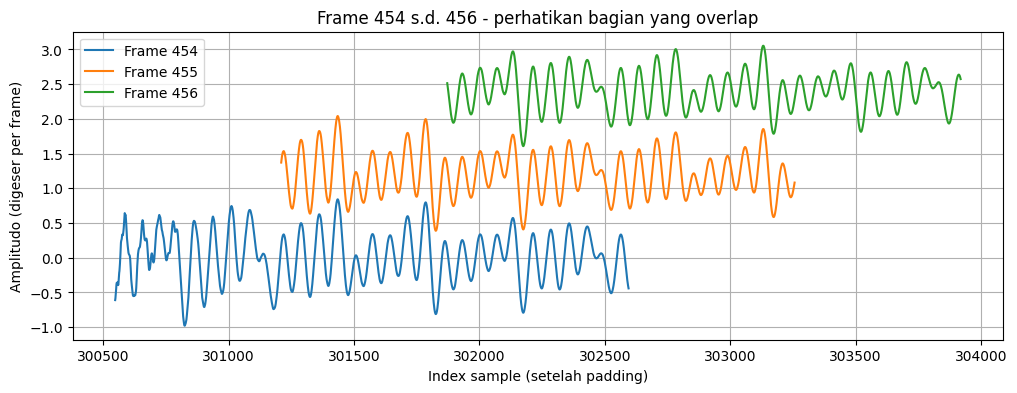

In [52]:
# Visualisasi 3 frame berurutan yang saling overlap
# (dimulai dari frame ke-454, bagian rekaman yang ada suaranya; frame-frame awal masih hening)
frame_len = np.round(sample_rate * (HOP_SIZE / 1000)).astype(int)
idx = 454

plt.figure(figsize=(12, 4))
for k, i in enumerate(range(idx, idx + 3)):
    start = i * frame_len
    x = np.arange(start, start + FFT_SIZE)          # posisi sample frame ke-i
    plt.plot(x, framed_audio[i] + k * 1.2, label=f"Frame {i}")   # digeser ke atas agar tidak tumpang tindih
plt.xlabel("Index sample (setelah padding)")
plt.ylabel("Amplitudo (digeser per frame)")
plt.title(f"Frame {idx} s.d. {idx+2} - perhatikan bagian yang overlap")
plt.legend()
plt.grid(True)
plt.show()

---
# Bagian 7 - Langkah 3: Windowing

## 7.1 Masalahnya

FFT mengasumsikan sinyal yang diberikan bersifat **periodik** — seolah-olah frame tersebut diulang terus-menerus. Padahal kalau kita memotong sinyal begitu saja, ujung awal dan akhir frame biasanya **tidak sama**. Saat "diulang", akan terjadi **lompatan nilai** mendadak di sambungannya, dan lompatan ini muncul di hasil FFT sebagai frekuensi-frekuensi palsu (**spectral leakage** / distorsi).

## 7.2 Solusinya: Window Function

**Window function** adalah fungsi yang nilainya **mendekati 0 di kedua ujung** dan **1 di tengah**. Setiap frame **dikalikan** dengan window ini, sehingga ujung-ujung frame menjadi halus mendekati 0 dan tidak ada lompatan.

$$\text{frame}_{win}[n] = \text{frame}[n] \times w[n]$$

Window yang kita pakai: **Hann (Hanning)**, salah satu yang paling umum di speech processing:

$$w[n] = 0.5 \left(1 - \cos\left(\frac{2\pi n}{N-1}\right)\right), \quad 0 \le n \le N-1$$

Tipe window lain yang tersedia: `bartlett`, `blackman`, `hamming`, `flattop`, dsb.

## 7.3 `get_window("hann", FFT_SIZE, fftbins=True)`

| Parameter | Arti |
|---|---|
| `"hann"` | jenis window |
| `FFT_SIZE` | panjang window — disamakan dengan panjang frame agar seluruh frame terkena window |
| `fftbins=True` | window dibuat *periodik* (cocok untuk analisis FFT) |

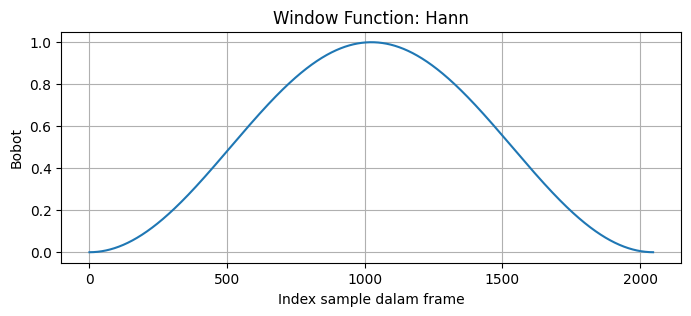

In [41]:
# Buat window Hann sepanjang 1 frame
window = get_window("hann", FFT_SIZE, fftbins=True)

plt.figure(figsize=(8, 3))
plt.plot(window)
plt.title("Window Function: Hann")
plt.xlabel("Index sample dalam frame")
plt.ylabel("Bobot")
plt.grid(True)
plt.show()

In [42]:
# Terapkan window ke SEMUA frame sekaligus (broadcasting NumPy: tiap baris dikali window)
audio_win = framed_audio * window

print(f"Shape sebelum windowing : {framed_audio.shape}")
print(f"Shape sesudah windowing : {audio_win.shape}")

Shape sebelum windowing : (1257, 2048)
Shape sesudah windowing : (1257, 2048)


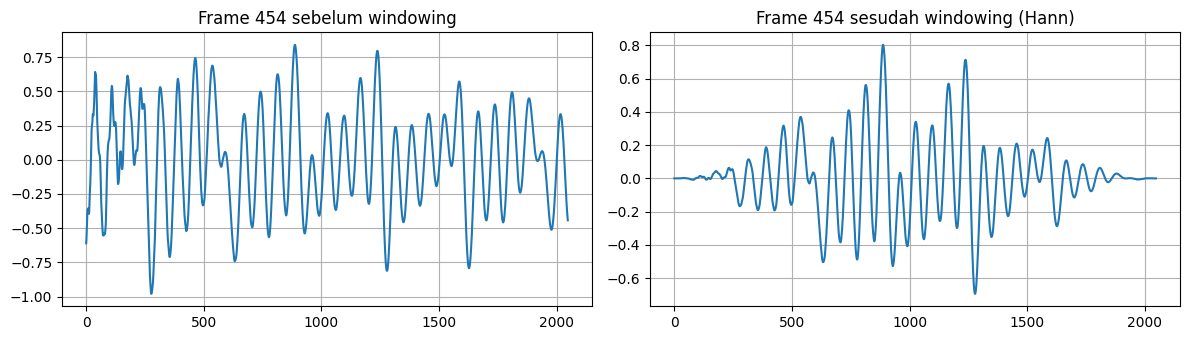

In [43]:
# Bandingkan 1 frame sebelum vs sesudah windowing (frame yang sama seperti di Bagian 6)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].plot(framed_audio[idx]);  ax[0].set_title(f"Frame {idx} sebelum windowing"); ax[0].grid(True)
ax[1].plot(audio_win[idx]);     ax[1].set_title(f"Frame {idx} sesudah windowing (Hann)"); ax[1].grid(True)
plt.tight_layout()
plt.show()

Perhatikan: setelah windowing, kedua ujung frame "dijepit" mendekati 0, sementara bagian tengahnya hampir tidak berubah.

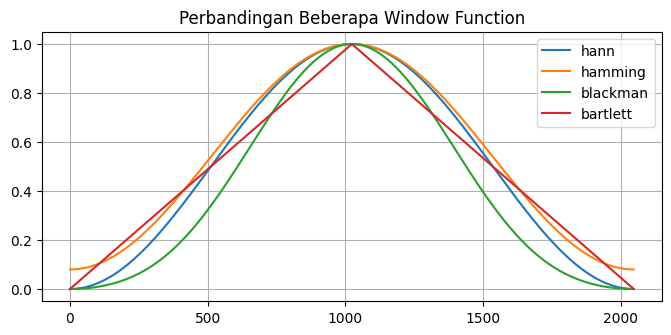

In [44]:
# Bonus: bentuk beberapa jenis window lain
plt.figure(figsize=(8, 3.5))
for nama in ["hann", "hamming", "blackman", "bartlett"]:
    plt.plot(get_window(nama, FFT_SIZE, fftbins=True), label=nama)
plt.title("Perbandingan Beberapa Window Function")
plt.legend()
plt.grid(True)
plt.show()

---
# Bagian 8 - Langkah 4: Fast Fourier Transform (FFT)

## 8.1 Apa yang dilakukan FFT?

**Fourier Transform** memecah sebuah sinyal menjadi jumlahan gelombang-gelombang sinus dengan frekuensi berbeda, lalu memberi tahu *seberapa besar* kontribusi tiap frekuensi. Hasilnya: sinyal berpindah dari **time domain** ke **frequency domain**.

Untuk sinyal diskrit (array), rumusnya disebut **DFT** (Discrete Fourier Transform):

$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j \frac{2\pi}{N} k n}, \quad k = 0, 1, \dots, N-1$$

- $x[n]$ : sample ke-$n$ dalam frame
- $X[k]$ : bilangan kompleks yang menyatakan besar (magnitude) dan fase frekuensi ke-$k$
- **FFT** = algoritma cepat untuk menghitung DFT (dari $O(N^2)$ menjadi $O(N \log N)$). Inilah kenapa `FFT_SIZE` dipilih pangkat 2.

## 8.2 Dua hal penting

1. **Hasil FFT simetris.** Dari `FFT_SIZE` output, separuh kedua hanyalah cerminan separuh pertama. Kita cukup simpan **`1 + FFT_SIZE // 2` = 1025** nilai pertama (frekuensi 0 Hz sampai `sample_rate / 2`).
2. **Hasilnya bilangan kompleks.** Untuk analisis kita butuh **power spectrum** = kuadrat dari magnitude:

$$P[k] = |X[k]|^2$$

## 8.3 Langkah di kode

1. Transpose `audio_win` supaya tiap **kolom** = 1 frame (memudahkan FFT per kolom).
2. Siapkan array kosong `audio_fft` berukuran `(1 + FFT_SIZE//2, jumlah_frame)` bertipe `complex64`.
3. Loop tiap frame: hitung FFT, ambil separuh pertama saja.
4. Transpose kembali agar bentuknya `(jumlah_frame, jumlah_frekuensi)`.
5. Hitung power spectrum.

In [45]:
# 1. Transpose: (jumlah frame, FFT_SIZE) -> (FFT_SIZE, jumlah frame). Tiap kolom = 1 frame
audio_winT = np.transpose(audio_win)
print(f"Shape audio_winT : {audio_winT.shape}")

# 2. Array kosong untuk hasil FFT. Baris = frekuensi (hanya separuh + 1), kolom = frame
#    dtype complex64 -> hasil FFT berupa bilangan kompleks
#    order='F' -> data disimpan per kolom di memori (lebih cepat karena kita mengisi per kolom)
audio_fft = np.empty((1 + FFT_SIZE // 2, audio_winT.shape[1]), dtype=np.complex64, order='F')

# 3. FFT untuk tiap frame (tiap kolom), ambil separuh pertama saja karena simetris
for i in range(audio_fft.shape[1]):
    audio_fft[:, i] = fft.fft(audio_winT[:, i], axis=0)[:audio_fft.shape[0]]

# 4. Transpose kembali: (jumlah frame, jumlah frekuensi)
audio_fft = np.transpose(audio_fft)
print(f"Shape audio_fft  : {audio_fft.shape}  -> (jumlah frame, jumlah bin frekuensi)")

# 5. Power spectrum = |X|^2
audio_power = np.square(np.abs(audio_fft))
print(f"Shape audio_power: {audio_power.shape}")

Shape audio_winT : (2048, 1257)
Shape audio_fft  : (1257, 1025)  -> (jumlah frame, jumlah bin frekuensi)
Shape audio_power: (1257, 1025)


## 8.4 Melihat spektrum 1 frame

Setiap baris `audio_power` adalah spektrum untuk 1 frame. Bin ke-$k$ mewakili frekuensi:

$$f_k = k \times \frac{\text{sample\_rate}}{\text{FFT\_SIZE}}$$

Kita tampilkan dalam **desibel (dB)** = $10 \log_{10}(P)$ supaya nilai yang sangat kecil dan sangat besar sama-sama terlihat.

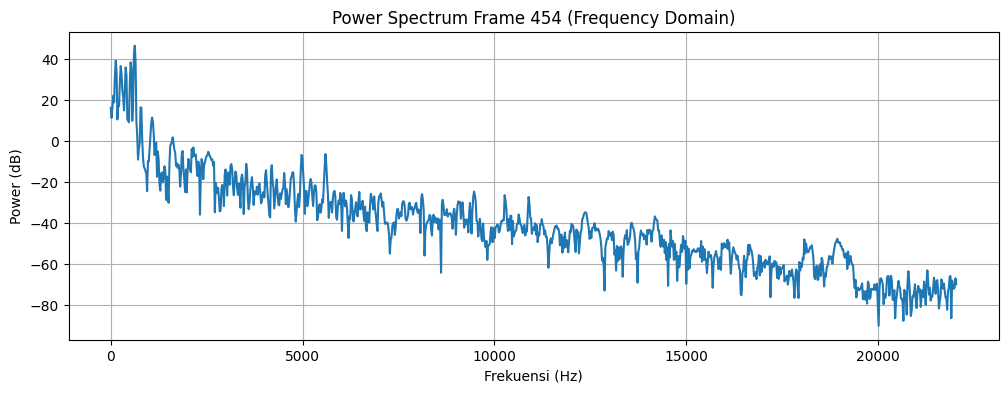

In [46]:
# Sumbu frekuensi untuk tiap bin: 0 Hz sampai sample_rate/2
freqs = np.arange(audio_power.shape[1]) * sample_rate / FFT_SIZE

plt.figure(figsize=(12, 4))
plt.plot(freqs, 10 * np.log10(audio_power[idx] + 1e-10))   # +1e-10 supaya tidak log(0)
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Power (dB)")
plt.title(f"Power Spectrum Frame {idx} (Frequency Domain)")
plt.grid(True)
plt.show()

## 8.5 Spectrogram: semua frame sekaligus

Kalau semua spektrum frame disusun berdampingan (sumbu X = waktu/frame, sumbu Y = frekuensi, warna = power), kita mendapatkan **spectrogram**. Ini adalah gambaran "time + frequency" sekaligus, dan menjadi bahan baku untuk langkah 5 (Mel Filterbank) di sesi berikutnya.

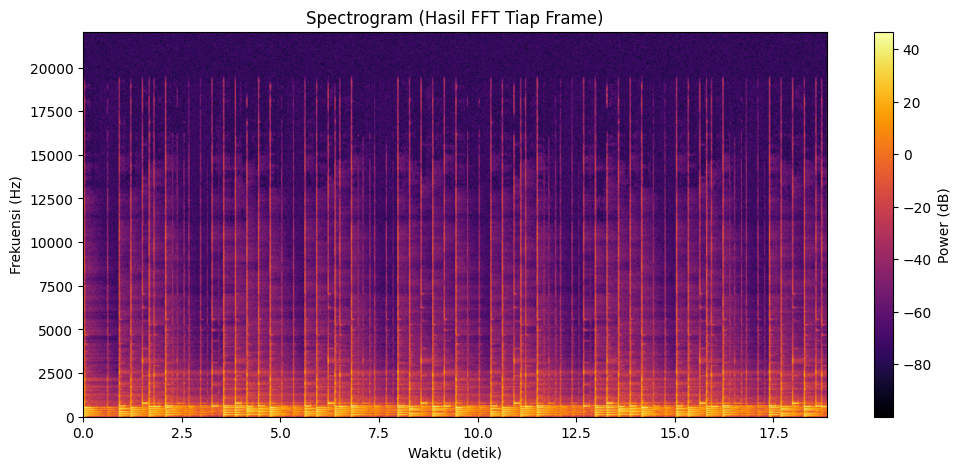

In [47]:
plt.figure(figsize=(12, 5))
plt.imshow(
    10 * np.log10(audio_power.T + 1e-10),        # transpose supaya frekuensi di sumbu Y
    aspect='auto',
    origin='lower',                               # frekuensi 0 Hz di bawah
    cmap='inferno',
    extent=[0, audio_duration, 0, sample_rate / 2]  # skala sumbu: waktu (s) & frekuensi (Hz)
)
plt.colorbar(label='Power (dB)')
plt.xlabel('Waktu (detik)')
plt.ylabel('Frekuensi (Hz)')
plt.title('Spectrogram (Hasil FFT Tiap Frame)')
plt.show()

> **Cara membaca spectrogram:** sumbu X = waktu, sumbu Y = frekuensi, warna terang = frekuensi yang kuat pada waktu tersebut. Bagian bawah (frekuensi rendah) biasanya paling terang karena di situlah sebagian besar energi suara berada. Garis-garis **horizontal** bertingkat adalah **harmonik** dari nada yang ditahan; garis **vertikal** adalah bunyi tiba-tiba (ketukan/konsonan letup) yang energinya tersebar ke semua frekuensi.
>
> Perhatikan juga betapa "penuh"-nya gambar ini: 1257 frame × 1025 bin frekuensi ≈ 1,3 juta angka. Inilah kenapa kita masih butuh langkah 5–6 untuk meringkasnya menjadi MFCC.

---
# Bagian 9 - Rangkuman & Preview Sesi 4

## Yang sudah kita lakukan hari ini

| Langkah | Fungsi / kode kunci | Input → Output |
|---|---|---|
| Baca audio | `wavfile.read()` | file `.wav` → `(sample_rate, audio)` |
| 1. Normalization | `audio / np.max(np.abs(audio))` | `(N,)` → `(N,)` rentang -1..1 |
| 2. Frame Blocking | `np.pad()` + slicing loop | `(N,)` → `(jumlah_frame, FFT_SIZE)` |
| 3. Windowing | `get_window("hann")` lalu `frames * window` | `(jumlah_frame, FFT_SIZE)` → sama |
| 4. FFT | `fft.fft()` per frame, ambil separuh, `np.abs()**2` | → `(jumlah_frame, 1 + FFT_SIZE//2)` power spectrum |

## Sesi 4 (MFCC Part 2)

| Langkah | Yang akan dilakukan |
|---|---|
| 5. Mel Filterbank | Membuat filter-filter segitiga pada skala Mel (memakai `freq_to_mel` / `mel_to_freq` dari Bagian 2), lalu mengalikannya dengan power spectrum → energi per pita Mel |
| 6. DCT | Mengambil `log` energi filterbank, lalu Discrete Cosine Transform → **Cepstral Coefficients** = MFCC |

Semua variabel yang kita punya sekarang (`audio_power`, `sample_rate`, `FFT_SIZE`) adalah **input langsung** untuk langkah 5.

---
# Latihan

1. Ubah `HOP_SIZE` menjadi `10` dan `25`. Jalankan ulang frame blocking. Bagaimana perubahan `framed_audio.shape`? Jelaskan kenapa.
2. Ubah `FFT_SIZE` menjadi `1024`. Berapa durasi 1 frame sekarang (dalam ms)? Berapa jumlah bin frekuensi hasil FFT?
3. Ganti window `"hann"` menjadi `"hamming"` lalu `"boxcar"` (window kotak = tanpa windowing). Bandingkan spectrogram-nya — mana yang tampak lebih "bersih"?
4. Ulangi seluruh proses (Bagian 4–8) untuk file `AudioWav.wav`. Perhatikan sample rate-nya berbeda: apa yang berubah pada sumbu frekuensi spectrogram?
5. (Tantangan) Tulis satu function `hitung_power_spectrum(path, FFT_SIZE, HOP_SIZE)` yang menggabungkan seluruh langkah 1–4 dan mengembalikan `audio_power` beserta `sample_rate`.